# Trabalho Final: Modelagem Estatística 
## Equipe
*   **Caio Cunha Franco** - 2650555
*   **Rodrigo Pinto Franco** - 2650089
*   **Alexandre Pinto Franco** - 2650081

# Importação de Bibliotecas

In [86]:
import stats
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import shapiro, levene, pearsonr, f_oneway, sem, t, probplot, mannwhitneyu, ttest_ind, ttest_rel, wilcoxon, chi2_contingency, kruskal
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Análise da Base

In [87]:
df = pd.read_excel("documentos/base-antecipacao-AULA.xlsx")
df.columns = df.columns.str.strip()

In [88]:
df.describe()

,id_operacao,data_operacao,score_credito,prazo_dias,volume_solicitado,taxa_pct,lucro_operacao,inadimplencia,horas_analise_antes,horas_analise_depois
count,720.000000,720,715.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000
mean,5360.500000,2025-07-07 18:51:59.999999744,612.474126,41.291667,9432.833222,2.770556,216.409264,0.127778,6.125472,5.784778
min,5001.000000,2025-01-07 00:00:00,300.000000,30.000000,190.920000,1.270000,3.460000,0.000000,1.500000,0.500000
25%,5180.750000,2025-04-05 00:00:00,543.000000,30.000000,2310.277500,2.379750,51.567500,0.000000,4.965000,4.370000
50%,5360.500000,2025-07-10 00:00:00,613.000000,45.000000,4877.300000,2.757000,114.770000,0.000000,6.100000,5.810000
75%,5540.250000,2025-10-07 06:00:00,676.000000,45.000000,10485.882500,3.160250,255.732500,0.000000,7.270000,7.140000
max,5720.000000,2025-12-31 00:00:00,850.000000,60.000000,193384.680000,4.312000,3260.880000,1.000000,12.970000,13.200000
std,207.990384,NaN,95.926897,11.840311,14486.393334,0.542879,328.241850,0.334074,1.725622,2.145163


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id_operacao           720 non-null    int64         
 1   data_operacao         720 non-null    datetime64[ns]
 2   segmento              720 non-null    object        
 3   canal                 720 non-null    object        
 4   porte                 720 non-null    object        
 5   score_credito         715 non-null    float64       
 6   prazo_dias            720 non-null    int64         
 7   volume_solicitado     720 non-null    float64       
 8   taxa_pct              720 non-null    float64       
 9   lucro_operacao        720 non-null    float64       
 10  inadimplencia         720 non-null    int64         
 11  horas_analise_antes   720 non-null    float64       
 12  horas_analise_depois  720 non-null    float64       
dtypes: datetime64[ns](1)

Quantas linhas e colunas? Onde estão os 5 ausentes?

In [90]:
print(f"""A base de dados possui {df.shape[0]} linhas e {df.shape[1]} colunas. """)

# Colunas com valores nulos
print("Colunas com Valores Nulos:\n")
print(df.isna().sum()[df.isna().sum() > 0])

print("Linhas com valores nulos:")
display(df[df.isna().any(axis=1)])

missing_pct = (
    df.isna().sum()
    .loc[lambda s: s > 0]
    .div(len(df))
    .mul(100)
)

print("\nSolução para casos nulos:")
print("Os valores nulos representam os seguintes percentuais do total de linhas:")

for coluna, percentual in missing_pct.items():
    print(f"- {coluna}: {percentual:.2f}%")

print(
    "\nPode-se remover essas linhas, pois a quantidade de dados restantes "
    "ainda é suficiente para análise. Substituí-las por zero poderia "
    "distorcer os resultados."
)

df = df.dropna()

A base de dados possui 720 linhas e 13 colunas. 
Colunas com Valores Nulos:

score_credito    5
dtype: int64
Linhas com valores nulos:


,id_operacao,data_operacao,segmento,canal,porte,score_credito,prazo_dias,volume_solicitado,taxa_pct,lucro_operacao,inadimplencia,horas_analise_antes,horas_analise_depois
100,5469,2025-02-24,Industria,Plataforma Web,Media,NaN,60,926.91,3.173,20.83,0,7.97,6.57
215,5437,2025-04-25,Servicos,Plataforma Web,Media,NaN,45,1644.61,3.518,45.62,0,4.94,4.08
467,5496,2025-09-01,Servicos,Plataforma Web,Micro,NaN,45,19546.09,2.606,374.28,1,4.43,2.09
571,5356,2025-10-26,Comercio,Gerente,Micro,NaN,45,9262.03,2.659,183.91,0,4.97,5.36
592,5423,2025-11-05,Comercio,Gerente,Micro,NaN,30,8368.35,2.909,203.92,0,5.99,6.58



Solução para casos nulos:
Os valores nulos representam os seguintes percentuais do total de linhas:
- score_credito: 0.69%

Pode-se remover essas linhas, pois a quantidade de dados restantes ainda é suficiente para análise. Substituí-las por zero poderia distorcer os resultados.


In [91]:
df = df.drop(columns=['id_operacao'])

## Análise de Valores distintos

In [92]:
for col in df.columns:
    print(f"\nValores únicos na coluna '{col}':")
    display(df[col].value_counts())


Valores únicos na coluna 'data_operacao':


data_operacao
2025-09-22    8
2025-11-06    7
2025-09-01    7
2025-06-15    7
2025-10-03    6
             ..
2025-02-03    1
2025-02-05    1
2025-02-11    1
2025-02-12    1
2025-12-31    1
Name: count, Length: 309, dtype: int64


Valores únicos na coluna 'segmento':


segmento
Industria    239
Comercio     238
Servicos     238
Name: count, dtype: int64


Valores únicos na coluna 'canal':


...

inadimplencia
0    624
1     91
Name: count, dtype: int64


Valores únicos na coluna 'horas_analise_antes':


horas_analise_antes
6.63    6
5.24    6
5.62    5
6.13    5
6.70    5
       ..
2.31    1
5.21    1
4.26    1
7.51    1
7.91    1
Name: count, Length: 435, dtype: int64


Valores únicos na coluna 'horas_analise_depois':


horas_analise_depois
5.96     7
4.23     5
4.73     5
6.51     5
6.73     5
        ..
4.72     1
8.23     1
11.48    1
10.67    1
7.73     1
Name: count, Length: 469, dtype: int64

## Adaptação de dados

In [93]:
df['valor_financeiro'] = (df['taxa_pct']/100) * df['volume_solicitado']
df[['volume_solicitado', 'taxa_pct', 'valor_financeiro']]

,volume_solicitado,taxa_pct,valor_financeiro
0,2917.51,2.472,72.120847
1,7123.80,2.508,178.664904
2,2076.15,2.318,48.125157
3,553.81,2.977,16.486924
4,3855.99,3.404,131.257900
...,...,...,...
715,15038.07,2.045,307.528531
716,741.29,2.587,19.177172
717,5704.90,3.582,204.349518
718,7936.24,2.865,227.373276


# Hipóteses

In [94]:
alpha = 0.05

print("H0: Não há diferença na taxa média entre Gerente e Plataforma Web")
print("H1: A taxa média É DIFERENTE entre Gerente e Plataforma Web\n")

H0: Não há diferença na taxa média entre Gerente e Plataforma Web
H1: A taxa média É DIFERENTE entre Gerente e Plataforma Web



# Premissas

score_credito é normal? volume_solicitado é normal? As variâncias são iguais?

Para Shapiro-Wilk e Levene, consideramos:

- *p > 0,05:* não rejeitamos a premissa.
- *p ≤ 0,05:* há evidência contra a premissa.

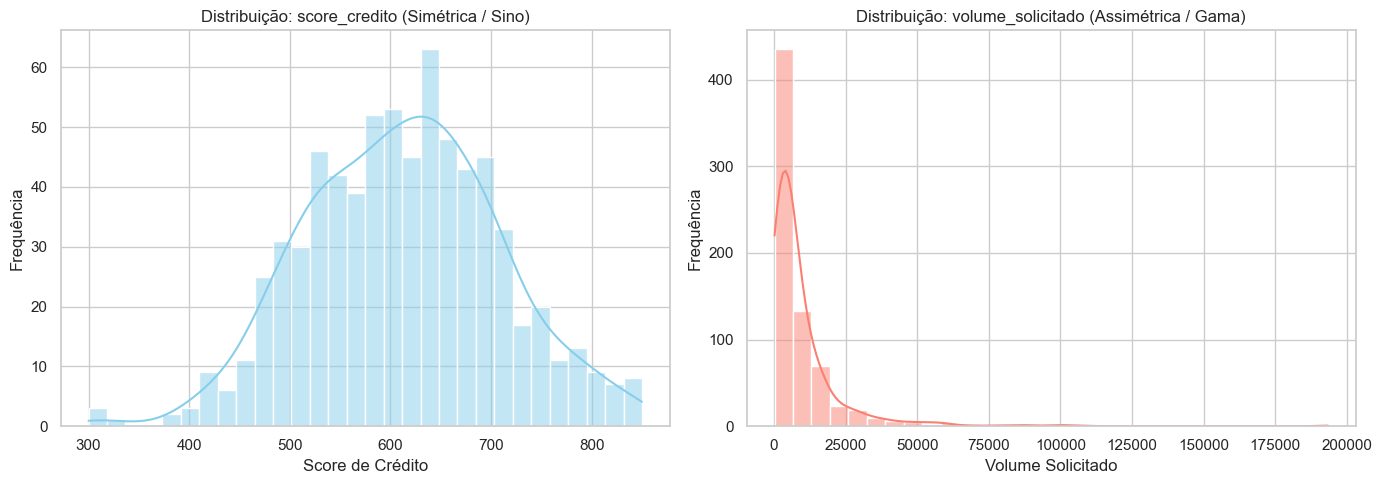

In [95]:
# Criação de uma figura lado a lado com apenas histogramas KDE

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

score = df["score_credito"].dropna()
volume = df["volume_solicitado"].dropna()

# 1. Histograma com KDE: score_credito
sns.histplot(score, kde=True, color='skyblue', bins=30, ax=axes[0])
axes[0].set_title("Distribuição: score_credito (Simétrica / Sino)")
axes[0].set_xlabel('Score de Crédito')
axes[0].set_ylabel('Frequência')

# 2. Histograma com KDE: volume_solicitado
sns.histplot(volume, kde=True, color='salmon', bins=30, ax=axes[1])
axes[1].set_title("Distribuição: volume_solicitado (Assimétrica / Gama)")
axes[1].set_xlabel('Volume Solicitado')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

In [96]:
# Normalidade
score = df["score_credito"].dropna()
volume = df["volume_solicitado"].dropna()

shapiro_score = shapiro(score)
shapiro_volume = shapiro(volume)

print("Shapiro-Wilk — score_credito")
print(f"W = {shapiro_score.statistic:.6f}; p = {shapiro_score.pvalue:.6g}")

print("\nShapiro-Wilk — volume_solicitado")
print(f"W = {shapiro_volume.statistic:.6f}; p = {shapiro_volume.pvalue:.6g}")

print("\nInterpretação:")
print("score_credito:", "compatível com normalidade." if shapiro_score.pvalue > alpha else "não compatível com normalidade.")
print("volume_solicitado:", "compatível com normalidade." if shapiro_volume.pvalue > alpha else "não compatível com normalidade.")

Shapiro-Wilk — score_credito
W = 0.996716; p = 0.150792

Shapiro-Wilk — volume_solicitado
W = 0.538381; p = 1.44311e-39

Interpretação:
score_credito: compatível com normalidade.
volume_solicitado: não compatível com normalidade.


In [97]:
# Homogeneidade das variâncias
taxa_gerente = df.loc[df["canal"] == "Gerente", "taxa_pct"]
taxa_web = df.loc[df["canal"] == "Plataforma Web", "taxa_pct"]

score_por_segmento = [
    grupo["score_credito"].dropna()
    for _, grupo in df.groupby("segmento")
]

levene_taxa = levene(taxa_gerente, taxa_web)
levene_score = levene(*score_por_segmento)

print("Levene — taxa_pct por canal")
print(f"W = {levene_taxa.statistic:.6f}; p = {levene_taxa.pvalue:.6g}")

print("\nLevene — score_credito por segmento")
print(f"W = {levene_score.statistic:.6f}; p = {levene_score.pvalue:.6g}")

Levene — taxa_pct por canal
W = 2.377410; p = 0.123545

Levene — score_credito por segmento
W = 2.293402; p = 0.101668


# Análise da Taxa Média

A taxa média é diferente entre Gerente e Plataforma Web?

=== Tabela Estatística Concatenada ('taxa_pct') ===


canal,Gerente,Plataforma Web
count,358.000000,357.000000
mean,2.821849,2.716283
std,0.558417,0.524152
min,1.270000,1.334000
25%,2.411000,2.359000
50%,2.801500,2.731000
75%,3.205500,3.052000
max,4.312000,4.188000



=== 1. Teste de Normalidade (Shapiro-Wilk) ===
Plataforma Web: W = 0.9975, p-valor = 8.7687e-01 -> Normal
Gerente:        W = 0.9963, p-valor = 5.6493e-01 -> Normal

=== 2. Teste de Homocedasticidade de Variâncias (Levene) ===
Estatística de Levene = 2.3774, p-valor = 1.2355e-01
Resultado: Variâncias Homogêneas (Variâncias Iguais)

=== 3. Estimativas e Intervalos de Confiança (IC 95%) por Canal ===
Canal: Plataforma Web  | n = 357     | Média: 2.7163 | IC 95%: [2.6617, 2.7708]
Canal: Gerente         | n = 358     | Média: 2.8218 | IC 95%: [2.7638, 2.8799]

=== 4. Teste de Hipótese (Comparação entre Canais) ===
H0: Não há diferença na taxa média entre Gerente e Plataforma Web
H1: A taxa média É DIFERENTE entre Gerente e Plataforma Web

Estimativa da Diferença (Gerente - Web): 0.1056 | IC 95% da Diferença: [0.0260, 0.1851]
Teste Aplicado: Teste t de Student (equal_var=True)
Estatística de teste: -2.6061
p-valor: 9.3501e-03
Conclusão (alpha = 0.05): Rejeita H0 (Existe diferença significa

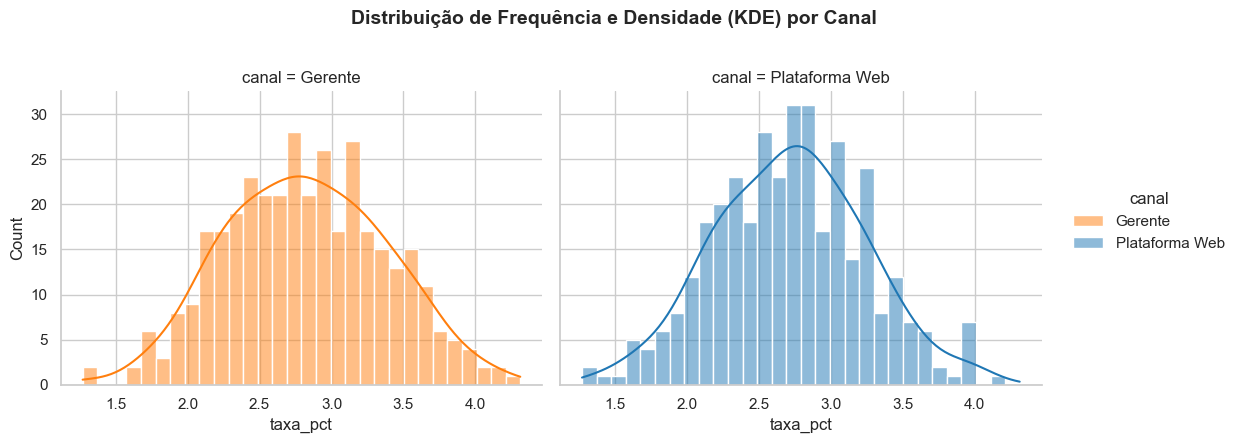

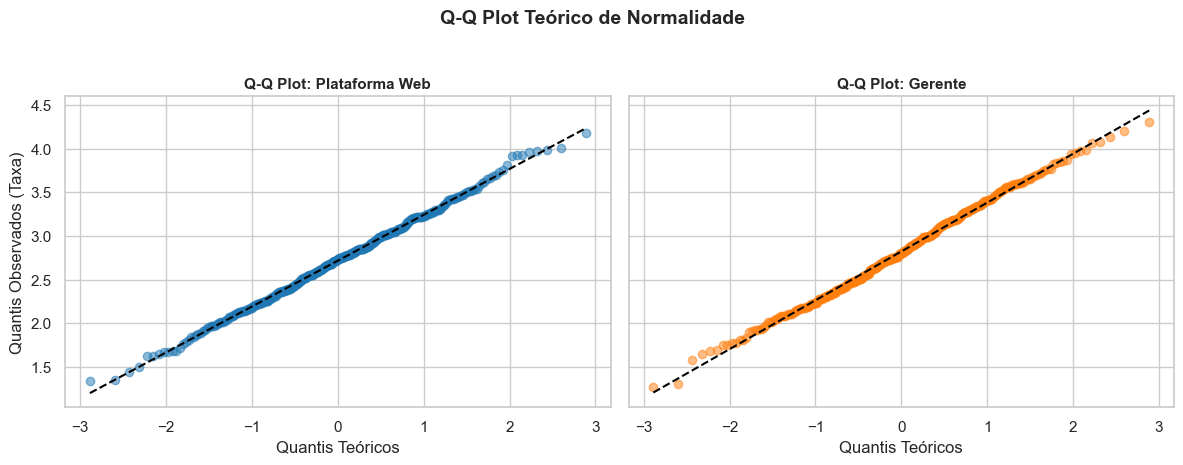


=== Conclusão Final ===
Nesse estudo podemos concluir que existe significativa diferença entre a taxa média de análise do Gerente e da Plataforma Web


In [98]:
sns.set_theme(style="whitegrid")

# 1. Leitura unificada no Dask
df_concat = df[
    df['canal'].isin(['Plataforma Web', 'Gerente'])
][['canal', 'taxa_pct', 'volume_solicitado']]

# 2. Tabela estatística descritiva
tabela_describe = df_concat.groupby('canal')['taxa_pct'].describe().T
print("=== Tabela Estatística Concatenada ('taxa_pct') ===")
display(tabela_describe)

# Separar os vetores de dados
taxa_web = df_concat[df_concat['canal'] == 'Plataforma Web']['taxa_pct'].dropna()
taxa_gerente = df_concat[df_concat['canal'] == 'Gerente']['taxa_pct'].dropna()

# 3. Teste de Normalidade (Shapiro-Wilk)
print("\n=== 1. Teste de Normalidade (Shapiro-Wilk) ===")
sample_web = taxa_web.sample(n=5000, random_state=42) if len(taxa_web) > 5000 else taxa_web
sample_gerente = taxa_gerente.sample(n=5000, random_state=42) if len(taxa_gerente) > 5000 else taxa_gerente

sw_web = shapiro(sample_web)
sw_gerente = shapiro(sample_gerente)

normal_web = sw_web.pvalue > alpha
normal_gerente = sw_gerente.pvalue > alpha

print(f"Plataforma Web: W = {sw_web.statistic:.4f}, p-valor = {sw_web.pvalue:.4e} -> {'Normal' if normal_web else 'Não Normal'}")
print(f"Gerente:        W = {sw_gerente.statistic:.4f}, p-valor = {sw_gerente.pvalue:.4e} -> {'Normal' if normal_gerente else 'Não Normal'}")

# 3.5. Teste de Homocedasticidade (Teste de Levene)
print("\n=== 2. Teste de Homocedasticidade de Variâncias (Levene) ===")
# center='median' é o padrão recomendado (mais robusto a desvios da normalidade)
stat_levene, p_levene = levene(taxa_web, taxa_gerente, center='median')
equal_var = p_levene > alpha

print(f"Estatística de Levene = {stat_levene:.4f}, p-valor = {p_levene:.4e}")
print(f"Resultado: {'Variâncias Homogêneas (Variâncias Iguais)' if equal_var else 'Variâncias Heterogêneas (Variâncias Diferentes)'}")

# 4. Reporte de Estimativa + Intervalo de Confiança (95%) + n por Canal
print("\n=== 3. Estimativas e Intervalos de Confiança (IC 95%) por Canal ===")
for canal, dados in [('Plataforma Web', taxa_web), ('Gerente', taxa_gerente)]:
    n = len(dados)
    media = dados.mean()
    se = sem(dados)
    ic_inf, ic_sup = t.interval(0.95, df=n-1, loc=media, scale=se) if n > 1 else (np.nan, np.nan)
    print(f"Canal: {canal:<15} | n = {n:<7} | Média: {media:.4f} | IC 95%: [{ic_inf:.4f}, {ic_sup:.4f}]")

# 5. Teste de Hipótese H1 e Intervalo da Diferença entre os Grupos
print("\n=== 4. Teste de Hipótese (Comparação entre Canais) ===")
print("H0: Não há diferença na taxa média entre Gerente e Plataforma Web")
print("H1: A taxa média É DIFERENTE entre Gerente e Plataforma Web\n")

if normal_web and normal_gerente:
    # Utiliza o booleano 'equal_var' definido anteriormente pelo Teste de Levene
    stat_t, p_val = ttest_ind(taxa_web, taxa_gerente, equal_var=equal_var)
    nome_teste = f"Teste t de Student ({'Welch / ' if not equal_var else ''}equal_var={equal_var})"
    
    # Cálculo do IC 95% para a diferença entre as médias
    mean_diff = taxa_gerente.mean() - taxa_web.mean()
    n1, n2 = len(taxa_gerente), len(taxa_web)
    s1, s2 = taxa_gerente.var(ddof=1), taxa_web.var(ddof=1)
    
    if equal_var:
        spooled = np.sqrt(((n1 - 1)*s1 + (n2 - 1)*s2) / (n1 + n2 - 2))
        se_diff = spooled * np.sqrt(1/n1 + 1/n2)
        df_diff = n1 + n2 - 2
    else:
        se_diff = np.sqrt(s1/n1 + s2/n2)
        df_diff = (s1/n1 + s2/n2)**2 / ((s1/n1)**2/(n1-1) + (s2/n2)**2/(n2-1))
        
    t_crit = t.ppf(0.975, df=df_diff)
    ci_diff = (mean_diff - t_crit * se_diff, mean_diff + t_crit * se_diff)
    
    print(f"Estimativa da Diferença (Gerente - Web): {mean_diff:.4f} | IC 95% da Diferença: [{ci_diff[0]:.4f}, {ci_diff[1]:.4f}]")
else:
    stat_t, p_val = mannwhitneyu(taxa_web, taxa_gerente, alternative='two-sided')
    nome_teste = "Teste de Mann-Whitney U (Não-paramétrico)"
    print("Nota: Teste não-paramétrico utilizado (focado em postos; IC para diferença direta de medianas omite-se nesta via padrão).")

conclusao = "Rejeita H0 (Existe diferença significativa - Aceita H1)" if p_val <= alpha else "Não rejeita H0 (Não há evidência de diferença)"

print(f"Teste Aplicado: {nome_teste}")
print(f"Estatística de teste: {stat_t:.4f}")
print(f"p-valor: {p_val:.4e}")
print(f"Conclusão (alpha = {alpha}): {conclusao}")

# 6. Gráfico 1: Distribuição de Frequência e Densidade (sns.displot)
g = sns.displot(
    data=df_concat,
    x='taxa_pct',
    col='canal',
    hue='canal',
    kde=True,
    bins=30,
    palette={'Plataforma Web': '#1f77b4', 'Gerente': '#ff7f0e'},
    height=4.5,
    aspect=1.2
)
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle('Distribuição de Frequência e Densidade (KDE) por Canal', fontsize=14, fontweight='bold')
plt.show()

# 7. Gráfico 2: Q-Q Plot Teórico de Normalidade
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
cores = {'Plataforma Web': '#1f77b4', 'Gerente': '#ff7f0e'}

for i, canal in enumerate(['Plataforma Web', 'Gerente']):
    dados_canal = df_concat[df_concat['canal'] == canal]['taxa_pct'].dropna()
    probplot(dados_canal, dist="norm", plot=axes[i])
    
    axes[i].get_lines()[0].set_color(cores[canal])
    axes[i].get_lines()[0].set_alpha(0.5)
    axes[i].get_lines()[1].set_color('black')
    axes[i].get_lines()[1].set_linestyle('--')
    axes[i].set_title(f'Q-Q Plot: {canal}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Quantis Teóricos')
    axes[i].set_ylabel('Quantis Observados (Taxa)' if i == 0 else '')

plt.suptitle('Q-Q Plot Teórico de Normalidade', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("\n=== Conclusão Final ===")
print("Nesse estudo podemos concluir que existe significativa diferença entre a taxa média de análise do Gerente e da Plataforma Web")

# Avaliação do Score Médio

O score médio é diferente entre os 3 segmentos? Quais pares diferem?

In [99]:
sns.set_theme(style="whitegrid")

# 1. Filtro dos dados
df_concat = df[['segmento', 'score_credito']].dropna()

# 2. Tabela estatística descritiva
tabela_describe = df_concat.groupby('segmento')['score_credito'].describe().T
print("=== Tabela Estatística Concatenada ('score_credito') ===")
display(tabela_describe)

# Separar os vetores de dados por segmento
segmentos = df_concat['segmento'].unique()
dados_por_seg = {seg: df_concat[df_concat['segmento'] == seg]['score_credito'] for seg in segmentos}

=== Tabela Estatística Concatenada ('score_credito') ===


segmento,Comercio,Industria,Servicos
count,238.000000,239.000000,238.000000
mean,597.638655,631.288703,608.415966
std,96.038954,89.696432,99.121028
min,300.000000,384.000000,300.000000
25%,527.000000,572.500000,539.250000
50%,601.000000,630.000000,613.000000
75%,656.750000,685.500000,681.000000
max,850.000000,850.000000,850.000000


In [100]:
# 3. Teste de Normalidade (Shapiro-Wilk)
print("\n=== 1. Teste de Normalidade (Shapiro-Wilk) ===")
normais = {}
for seg, dados in dados_por_seg.items():
    sample = dados.sample(n=5000, random_state=42) if len(dados) > 5000 else dados
    sw = shapiro(sample)
    normais[seg] = sw.pvalue > alpha
    print(f"Segmento: {seg:<15} | W = {sw.statistic:.4f}, p-valor = {sw.pvalue:.4e} -> {'Normal' if normais[seg] else 'Não Normal'}")

todos_normais = all(normais.values())

# 3.5. Teste de Homocedasticidade (Teste de Levene)
print("\n=== 2. Teste de Homocedasticidade de Variâncias (Levene) ===")
stat_levene, p_levene = levene(*dados_por_seg.values(), center='median')
equal_var = p_levene > alpha

print(f"Estatística de Levene = {stat_levene:.4f}, p-valor = {p_levene:.4e}")
print(f"Resultado: {'Variâncias Homogêneas (Variâncias Iguais)' if equal_var else 'Variâncias Heterogêneas (Variâncias Diferentes)'}")

# 4. Estimativas e Intervalos de Confiança (IC 95%) por Segmento
print("\n=== 3. Estimativas e Intervalos de Confiança (IC 95%) por Segmento ===")
for seg, dados in dados_por_seg.items():
    n = len(dados)
    media = dados.mean()
    se = sem(dados)
    ic_inf, ic_sup = t.interval(0.95, df=n-1, loc=media, scale=se) if n > 1 else (np.nan, np.nan)
    print(f"Segmento: {seg:<15} | n = {n:<7} | Média: {media:.4f} | IC 95%: [{ic_inf:.4f}, {ic_sup:.4f}]")


=== 1. Teste de Normalidade (Shapiro-Wilk) ===
Segmento: Industria       | W = 0.9909, p-valor = 1.4388e-01 -> Normal
Segmento: Comercio        | W = 0.9936, p-valor = 3.9774e-01 -> Normal
Segmento: Servicos        | W = 0.9911, p-valor = 1.5816e-01 -> Normal

=== 2. Teste de Homocedasticidade de Variâncias (Levene) ===
Estatística de Levene = 2.2934, p-valor = 1.0167e-01
Resultado: Variâncias Homogêneas (Variâncias Iguais)

=== 3. Estimativas e Intervalos de Confiança (IC 95%) por Segmento ===
Segmento: Industria       | n = 239     | Média: 631.2887 | IC 95%: [619.8589, 642.7185]
Segmento: Comercio        | n = 238     | Média: 597.6387 | IC 95%: [585.3747, 609.9026]
Segmento: Servicos        | n = 238     | Média: 608.4160 | IC 95%: [595.7584, 621.0735]


In [101]:
# 5. Teste de Hipótese (ANOVA/Tukey se normal, ou Kruskal-Wallis se não-normal)
print("\n=== 4. Teste de Hipótese (Comparação Geral e Par a Par) ===")
print("H0: Não há diferença no score médio entre os 3 segmentos")
print("H1: Pelo menos um segmento possui score médio diferente\n")

if todos_normais:
    stat, p_val = f_oneway(*dados_por_seg.values())
    nome_teste = "ANOVA One-Way"
    print(f"Estatística de Teste ({nome_teste}): {stat:.4f} | p-valor: {p_val:.4e}")
    
    if p_val <= alpha:
        print("\n=== Teste Post-Hoc (Tukey HSD - Com IC 95% das Diferenças) ===")
        tukey = pairwise_tukeyhsd(endog=df_concat['score_credito'], groups=df_concat['segmento'], alpha=alpha)
        print(tukey)
else:
    stat, p_val = kruskal(*dados_por_seg.values())
    nome_teste = "Kruskal-Wallis (Não-paramétrico)"
    print(f"Estatística de Teste ({nome_teste}): {stat:.4f} | p-valor: {p_val:.4e}")
    print("Nota: Como os dados não seguem distribuição normal, recomenda-se avaliar testes não-paramétricos de comparação par a par (ex: Teste de Dunn).")

conclusao = "Rejeita H0 (Existe diferença significativa em pelo menos um par)" if p_val <= alpha else "Não rejeita H0 (Não há evidência de diferença entre segmentos)"
print(f"\nConclusão Geral (alpha = {alpha}): {conclusao}")


=== 4. Teste de Hipótese (Comparação Geral e Par a Par) ===
H0: Não há diferença no score médio entre os 3 segmentos
H1: Pelo menos um segmento possui score médio diferente

Estatística de Teste (ANOVA One-Way): 7.8021 | p-valor: 4.4483e-04

=== Teste Post-Hoc (Tukey HSD - Com IC 95% das Diferenças) ===
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower    upper  reject
-----------------------------------------------------------
 Comercio Industria    33.65 0.0004  13.2126 54.0875   True
 Comercio  Servicos  10.7773 0.4316  -9.6815 31.2362  False
Industria  Servicos -22.8727 0.0238 -43.3102 -2.4353   True
-----------------------------------------------------------

Conclusão Geral (alpha = 0.05): Rejeita H0 (Existe diferença significativa em pelo menos um par)


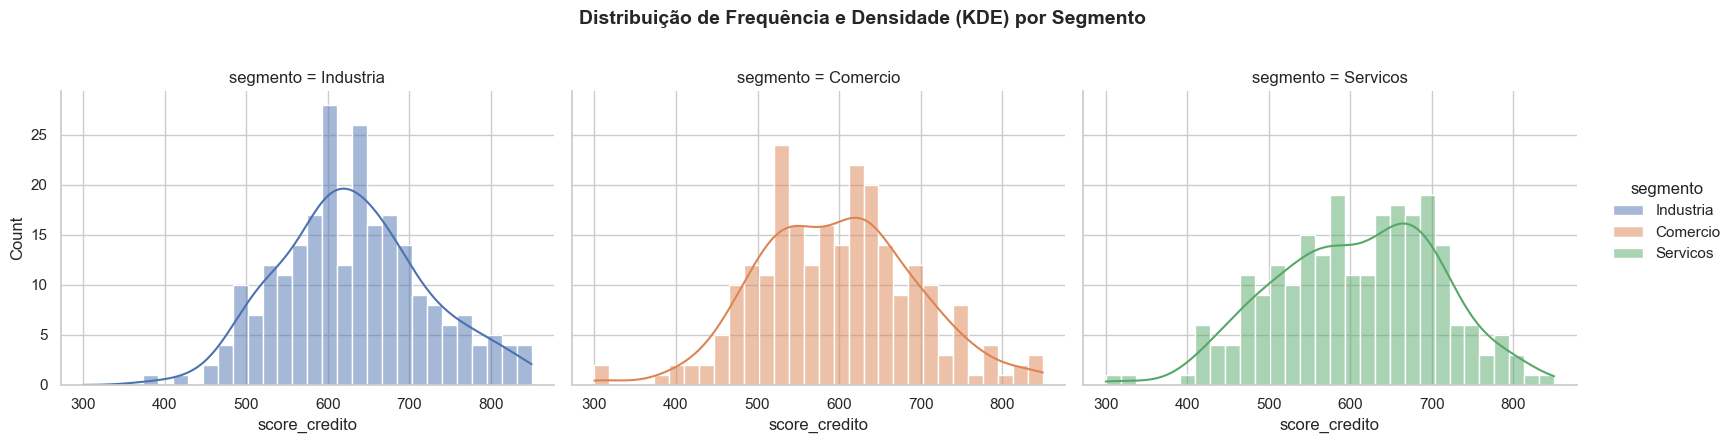

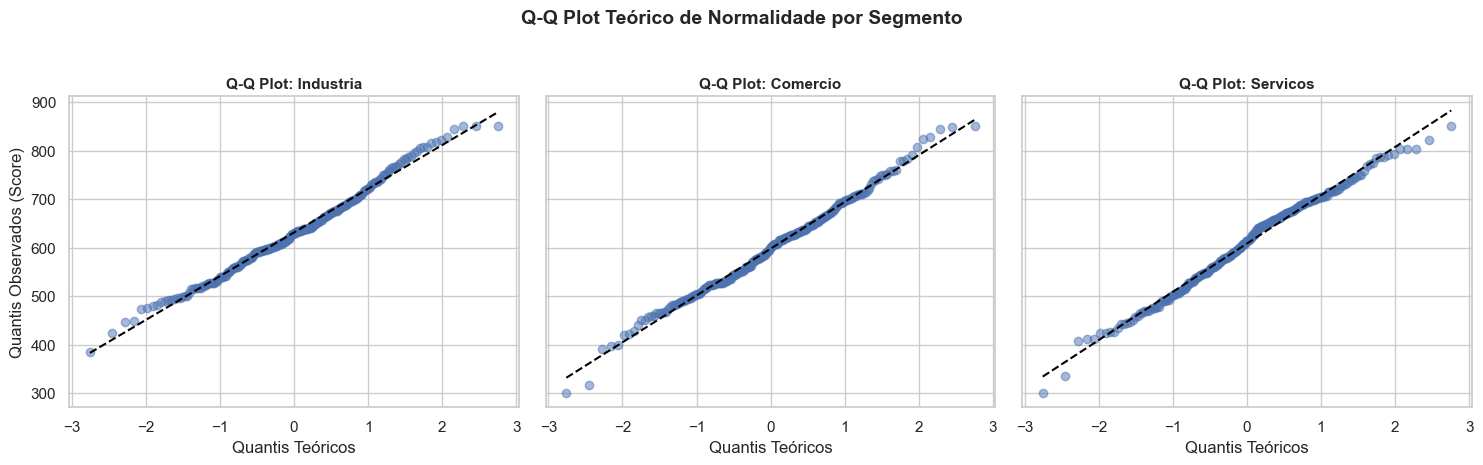


=== Conclusão Final ===
Com base nos testes executados, confirma-se que o score médio difere significativamente entre os segmentos analisados.


In [102]:
# 6. Gráfico 1: Distribuição de Frequência e Densidade (sns.displot)
g = sns.displot(
    data=df_concat,
    x='score_credito',
    col='segmento',
    hue='segmento',
    kde=True,
    bins=30,
    height=4.5,
    aspect=1.2
)
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle('Distribuição de Frequência e Densidade (KDE) por Segmento', fontsize=14, fontweight='bold')
plt.show()

# 7. Gráfico 2: Q-Q Plot Teórico de Normalidade
num_segs = len(segmentos)
fig, axes = plt.subplots(1, num_segs, figsize=(5 * num_segs, 4.5), sharey=True)

for i, seg in enumerate(segmentos):
    dados_seg = dados_por_seg[seg]
    ax = axes[i] if num_segs > 1 else axes
    probplot(dados_seg, dist="norm", plot=ax)
    
    ax.get_lines()[0].set_alpha(0.5)
    ax.get_lines()[1].set_color('black')
    ax.get_lines()[1].set_linestyle('--')
    ax.set_title(f'Q-Q Plot: {seg}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Quantis Teóricos')
    ax.set_ylabel('Quantis Observados (Score)' if i == 0 else '')

plt.suptitle('Q-Q Plot Teórico de Normalidade por Segmento', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("\n=== Conclusão Final ===")
if p_val <= alpha:
    print("Com base nos testes executados, confirma-se que o score médio difere significativamente entre os segmentos analisados.")
else:
    print("Não foram encontradas evidências estatisticamente significativas de diferença no score médio entre os segmentos.")

# Redução Horas Análise

O novo sistema reduziu as horas de análise? De quanto foi o ganho?

=== Tabela Estatística Concatenada (Antes vs Depois) ===


,count,mean,std,min,25%,50%,75%,max
horas_analise_antes,715.0,6.128727,1.727993,1.5,4.97,6.11,7.27,12.97
horas_analise_depois,715.0,5.790713,2.146793,0.5,4.38,5.81,7.14,13.20



=== 1. Teste de Normalidade (Shapiro-Wilk) ===
'horas_analise_antes':  W = 0.9971, p-valor = 2.2753e-01 -> Normal
'horas_analise_depois': W = 0.9965, p-valor = 1.1306e-01 -> Normal
Diferença (Antes-Depois): W = 0.9989, p-valor = 9.4696e-01 -> Normal

=== 2. Estimativas e Intervalos de Confiança (IC 95%) Pareados ===
Variável: horas_analise_antes  | n = 715     | Média: 6.1287 | IC 95%: [6.0019, 6.2556]
Variável: horas_analise_depois | n = 715     | Média: 5.7907 | IC 95%: [5.6331, 5.9483]
Diferença Média (Antes - Depois): | n = 715     | Média: 0.3380 | IC 95%: [0.2436, 0.4324]

=== 3. Teste de Hipótese (O novo sistema reduziu o tempo?) ===
H0: O tempo médio NÃO reduziu (Antes <= Depois)
H1: O novo sistema REDUZIU o tempo médio de análise (Antes > Depois)

Teste Aplicado: Teste t Pareado Unicaudal
Estatística de teste: 7.0307
p-valor (Unicaudal): 2.4062e-12
Decisão (alpha = 0.05): SIM, reduziu de forma estatisticamente significativa (Rejeita H0)


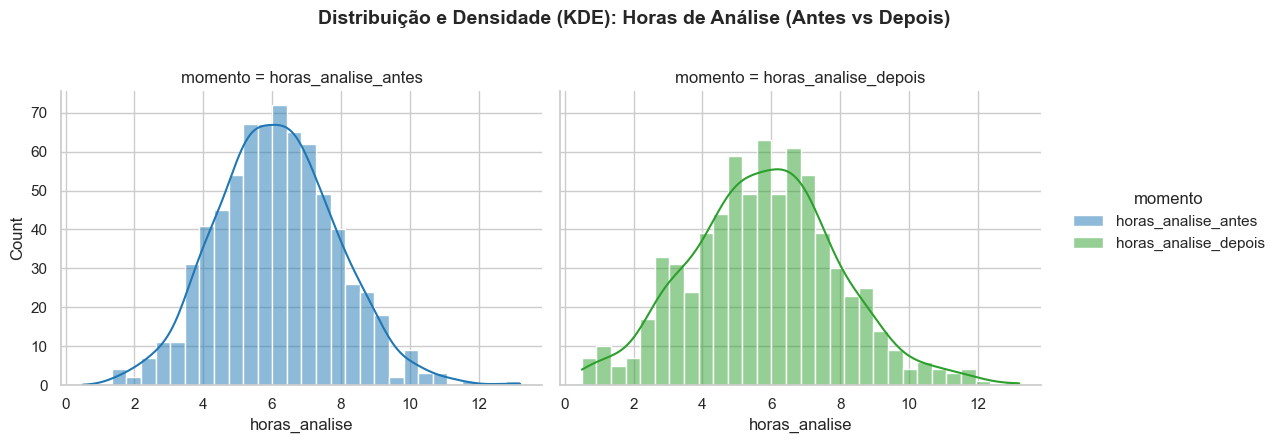

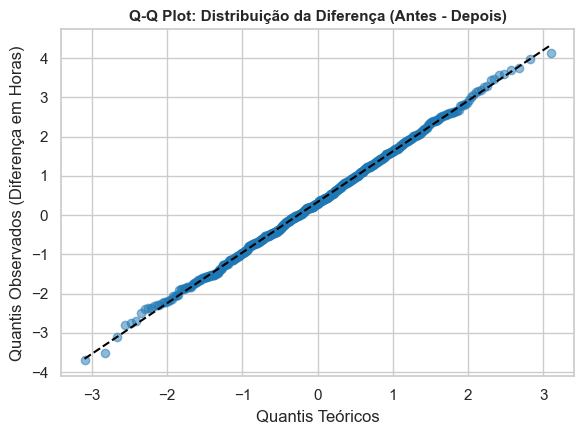

O novo sistema reduziu o tempo médio de análise.
- Redução média estimada: 0.34 horas por operação (IC 95%: [0.24, 0.43]).
- O resultado é estatisticamente significativo (p-valor = 2.4062e-12 < alpha = 0.05).


In [103]:
sns.set_theme(style="whitegrid")

# 1. Leitura e limpeza unificada das duas colunas no Dask (apenas pares completos)
df_pareado = df[['horas_analise_antes', 'horas_analise_depois']]

# Tabela estatística descritiva pareada
print("=== Tabela Estatística Concatenada (Antes vs Depois) ===")
display(df_pareado.describe().T)

antes = df_pareado['horas_analise_antes']
depois = df_pareado['horas_analise_depois']
diferenca = antes - depois  # Valor positivo indica que 'Antes' era maior que 'Depois' (Redução)

# 2. Teste de Normalidade (Shapiro-Wilk)
print("\n=== 1. Teste de Normalidade (Shapiro-Wilk) ===")
sample_dif = diferenca.sample(n=5000, random_state=42) if len(diferenca) > 5000 else diferenca
sw_dif = shapiro(sample_dif)
normal_dif = sw_dif.pvalue > alpha

sample_antes = antes.sample(n=5000, random_state=42) if len(antes) > 5000 else antes
sample_depois = depois.sample(n=5000, random_state=42) if len(depois) > 5000 else depois

sw_antes = shapiro(sample_antes)
sw_depois = shapiro(sample_depois)

print(f"'horas_analise_antes':  W = {sw_antes.statistic:.4f}, p-valor = {sw_antes.pvalue:.4e} -> {'Normal' if sw_antes.pvalue > alpha else 'Não Normal'}")
print(f"'horas_analise_depois': W = {sw_depois.statistic:.4f}, p-valor = {sw_depois.pvalue:.4e} -> {'Normal' if sw_depois.pvalue > alpha else 'Não Normal'}")
print(f"Diferença (Antes-Depois): W = {sw_dif.statistic:.4f}, p-valor = {sw_dif.pvalue:.4e} -> {'Normal' if normal_dif else 'Não Normal'}")

# 3. Reporte de Estimativa + Intervalo de Confiança (IC 95%) + n
print("\n=== 2. Estimativas e Intervalos de Confiança (IC 95%) Pareados ===")
for nome, dados in [('horas_analise_antes', antes), ('horas_analise_depois', depois)]:
    n = len(dados)
    media = dados.mean()
    se = sem(dados)
    ic_inf, ic_sup = t.interval(0.95, df=n-1, loc=media, scale=se)
    print(f"Variável: {nome:<20} | n = {n:<7} | Média: {media:.4f} | IC 95%: [{ic_inf:.4f}, {ic_sup:.4f}]")

# Estimativa e IC 95% da DIFERENÇA
n_dif = len(diferenca)
mean_dif = diferenca.mean()
se_dif = sem(diferenca)
ic_dif_inf, ic_dif_sup = t.interval(0.95, df=n_dif-1, loc=mean_dif, scale=se_dif)
print(f"Diferença Média (Antes - Depois): | n = {n_dif:<7} | Média: {mean_dif:.4f} | IC 95%: [{ic_dif_inf:.4f}, {ic_dif_sup:.4f}]")

# 4. Teste de Hipótese para Redução (Unicaudal: H1: Antes > Depois => Diferença > 0)
print("\n=== 3. Teste de Hipótese (O novo sistema reduziu o tempo?) ===")
print("H0: O tempo médio NÃO reduziu (Antes <= Depois)")
print("H1: O novo sistema REDUZIU o tempo médio de análise (Antes > Depois)\n")

if normal_dif:
    # Teste t Pareado Unicaudal (alternative='greater' pois testamos antes - depois > 0)
    stat_t, p_val_unic = ttest_rel(antes, depois, alternative='greater')
    nome_teste = "Teste t Pareado Unicaudal"
else:
    # Teste de Wilcoxon Unicaudal
    stat_t, p_val_unic = wilcoxon(antes, depois, alternative='greater')
    nome_teste = "Teste de Wilcoxon Unicaudal (Não-paramétrico)"

conclusao_reducao = "SIM, reduziu de forma estatisticamente significativa (Rejeita H0)" if (p_val_unic <= alpha and mean_dif > 0) else "NÃO há evidências estatísticas suficientes de redução (Não rejeita H0)"

print(f"Teste Aplicado: {nome_teste}")
print(f"Estatística de teste: {stat_t:.4f}")
print(f"p-valor (Unicaudal): {p_val_unic:.4e}")
print(f"Decisão (alpha = {alpha}): {conclusao_reducao}")

# 5. Gráfico 1: Distribuição de Frequência e Densidade (KDE)
df_melted = df_pareado.melt(var_name='momento', value_name='horas_analise')

g = sns.displot(
    data=df_melted,
    x='horas_analise',
    col='momento',
    hue='momento',
    kde=True,
    bins=30,
    palette={'horas_analise_antes': '#1f77b4', 'horas_analise_depois': '#2ca02c'},
    height=4.5,
    aspect=1.2
)
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle('Distribuição e Densidade (KDE): Horas de Análise (Antes vs Depois)', fontsize=14, fontweight='bold')
plt.show()

# 6. Gráfico 2: Q-Q Plot Teórico da DIFERENÇA
fig, ax = plt.subplots(figsize=(6, 4.5))
probplot(sample_dif, dist="norm", plot=ax)
ax.get_lines()[0].set_color('#1f77b4')
ax.get_lines()[0].set_alpha(0.5)
ax.get_lines()[1].set_color('black')
ax.get_lines()[1].set_linestyle('--')
ax.set_title('Q-Q Plot: Distribuição da Diferença (Antes - Depois)', fontsize=11, fontweight='bold')
ax.set_xlabel('Quantis Teóricos')
ax.set_ylabel('Quantis Observados (Diferença em Horas)')

plt.tight_layout()
plt.show()


if p_val_unic <= alpha and mean_dif > 0:
    print(f"O novo sistema reduziu o tempo médio de análise.")
    print(f"- Redução média estimada: {mean_dif:.2f} horas por operação (IC 95%: [{ic_dif_inf:.2f}, {ic_dif_sup:.2f}]).")
    print(f"- O resultado é estatisticamente significativo (p-valor = {p_val_unic:.4e} < alpha = {alpha}).")
elif mean_dif > 0:
    print(f"NÃO É POSSÍVEL AFIRMAR. Houve uma queda nominal de {mean_dif:.2f} horas, porém a diferença NÃO é estatisticamente significativa (p-valor = {p_val_unic:.4e} > alpha = {alpha}).")
else:
    print(f"O tempo médio após o novo sistema aumentou em {abs(mean_dif):.2f} horas por operação.")
print("="*70)

# Score vs Taxa

Score e taxa andam juntos? Quanto de taxa vale 100 pontos de score?

In [104]:
corr = pearsonr(score, df.loc[score.index, "taxa_pct"])

X = sm.add_constant(score)
y = df.loc[score.index, "taxa_pct"]
modelo = sm.OLS(y, X).fit()

beta = modelo.params["score_credito"]
ic_beta = modelo.conf_int().loc["score_credito"]

efeito_100 = beta * 100
ic_efeito_100 = (ic_beta[0] * 100, ic_beta[1] * 100)

print(f"Pearson r = {corr.statistic:.3f}")
print(f"p = {corr.pvalue:.6g}")
print(f"n = {len(score)}")

print("\nModelo:")
print(f"taxa = {modelo.params['const']:.4f} + ({beta:.6f}) × score")

print(f"\nEfeito estimado para +100 pontos: {efeito_100:.3f} p.p.")
print(f"IC95%: [{ic_efeito_100[0]:.3f}, {ic_efeito_100[1]:.3f}] p.p.")

print("\nConclusão:",
      "há associação negativa estatisticamente significativa."
      if corr.pvalue < alpha
      else "não há evidência de associação linear significativa.")

Pearson r = -0.554
p = 1.09944e-58
n = 715

Modelo:
taxa = 4.6916 + (-0.003139) × score

Efeito estimado para +100 pontos: -0.314 p.p.
IC95%: [-0.349, -0.279] p.p.

Conclusão: há associação negativa estatisticamente significativa.


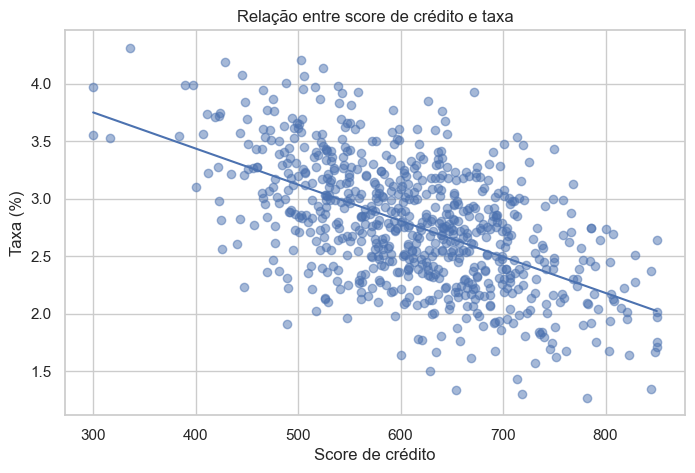

In [105]:
plt.figure(figsize=(8, 5))
plt.scatter(score, y, alpha=0.5)
x_line = np.linspace(score.min(), score.max(), 100)
y_line = modelo.params["const"] + beta * x_line
plt.plot(x_line, y_line)
plt.title("Relação entre score de crédito e taxa")
plt.xlabel("Score de crédito")
plt.ylabel("Taxa (%)")
plt.show()

Os dados demonstram uma correlação negativa moderada a forte ($r = -0,554$, $p = 1,09944 \times 10^{-58}$, $n = 715$), indicando que clientes com melhor score de crédito tendem a pagar taxas menores. 

Para cada acréscimo de 100 pontos no score de crédito, a taxa cobrada diminui em média 0,314 p.p. (com um intervalo de confiança de 95% variando entre $-0,349$ e $-0,279$ p.p.).

Natureza da Relação: Ressalta-se que a análise comprova uma relação de associação, e não necessariamente de causalidade direta.

SIM. Clientes com score melhor tendem a pagar taxa menor. A cada 100 pontos adicionais de score, a taxa varia em -0.314 p.p. em média (IC95% -0.349 a -0.279; n=715; p=1.09944e-58).

Estimativa: Redução de $-0,314$ p.p. na taxa  Intervalo: IC 95% $[-0,349, -0,279]$ p.p.  n: 720

# Dependencia da Indadimplência

A inadimplência depende do canal? E do porte?

Para avaliar se existe associação entre duas variáveis categóricas, será utilizado o **Teste do Qui-Quadrado**  para descobrir se existe relação estatística entre duas variáveis categóricas, acompanhado pelo **V de Cramér** para medir a força dessa associação



In [106]:
def comparativo_colunas(df, coluna_binaria, coluna_categorica):
    # 1. Tabela de Frequência cruzada
    tabela_contingencia = pd.crosstab(df[coluna_binaria], df[coluna_categorica])

    # 2. Teste do Qui-Quadrado 
    chi2, p_valor, dof, esperado = chi2_contingency(tabela_contingencia)

    # 3. Calculo do V de Cramér
    somatorio = tabela_contingencia.sum().sum()
    min_dim = min(tabela_contingencia.shape[0] - 1, tabela_contingencia.shape[1] - 1)
    v_cramer = np.sqrt(chi2 / (n * min_dim))

    print("\n=== Teste de Hipótese (Qui-Quadrado) e Tamanho do Efeito ===")
    print(f"H0: As variáveis '{coluna_binaria}' e '{coluna_categorica}' são INDEPENDENTES.")
    print(f"H1: Existe DEPENDÊNCIA significativa entre '{coluna_binaria}' e '{coluna_categorica}'.\n")

    print(f'Estatistica do Qui-Quadrado: {chi2:.4f}')
    print(f'Graus de Liberdade: {dof:.4f}')
    print(f'P-Valor: {p_valor:.4f}')
    print(f'V-Crámer: {v_cramer:.4f}')

    if v_cramer < 0.1:
        efeito = "Desprezível / Muito Fraco"
    elif v_cramer < 0.3:
        efeito = "Fraco"
    elif v_cramer < 0.5:
        efeito = "Moderado"
    else:
        efeito = "Forte"

    print(f"Intensidade da Associação:  {efeito}")

    print("\n=== Conclusão da Análise ===")
    if p_valor < alpha:
        print(f"-> Existe dependência estatística significativa (p < 0.05) entre as colunas {coluna_binaria} e {coluna_categorica}")
    else:
        print(f"-> Não Existe dependência estatística significativa (p >= 0.05), as colunas {coluna_binaria} e {coluna_categorica} são independentes")


    #4. Gráfico de Proporções Acumuladas (Stacked Bar Chart)
    plt.figure(figsize=(10, 5))
    tabela_contingencia.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='viridis')
    
    plt.title(f'Proporção de {coluna_binaria} por {coluna_categorica}', fontsize=14, fontweight='bold')
    plt.xlabel(coluna_categorica.capitalize(), fontsize=12)
    plt.ylabel('Percentual (%)', fontsize=12)
    plt.legend(title=coluna_binaria.capitalize(), bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=0 if len(tabela_contingencia.index) <= 4 else 45)
    plt.tight_layout()
    plt.show()   


=== Teste de Hipótese (Qui-Quadrado) e Tamanho do Efeito ===
H0: As variáveis 'inadimplencia' e 'canal' são INDEPENDENTES.
H1: Existe DEPENDÊNCIA significativa entre 'inadimplencia' e 'canal'.

Estatistica do Qui-Quadrado: 12.9966
Graus de Liberdade: 1.0000
P-Valor: 0.0003
V-Crámer: 0.1348
Intensidade da Associação:  Fraco

=== Conclusão da Análise ===
-> Existe dependência estatística significativa (p < 0.05) entre as colunas inadimplencia e canal


<Figure size 1000x500 with 0 Axes>

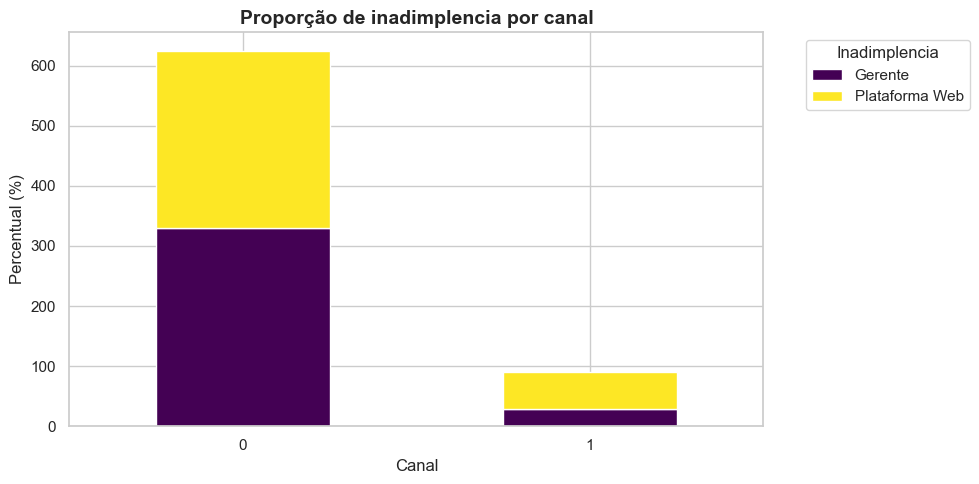

In [107]:
comparativo_colunas(df, 'inadimplencia', 'canal')


=== Teste de Hipótese (Qui-Quadrado) e Tamanho do Efeito ===
H0: As variáveis 'inadimplencia' e 'porte' são INDEPENDENTES.
H1: Existe DEPENDÊNCIA significativa entre 'inadimplencia' e 'porte'.

Estatistica do Qui-Quadrado: 3.6731
Graus de Liberdade: 2.0000
P-Valor: 0.1594
V-Crámer: 0.0717
Intensidade da Associação:  Desprezível / Muito Fraco

=== Conclusão da Análise ===
-> Não Existe dependência estatística significativa (p >= 0.05), as colunas inadimplencia e porte são independentes


<Figure size 1000x500 with 0 Axes>

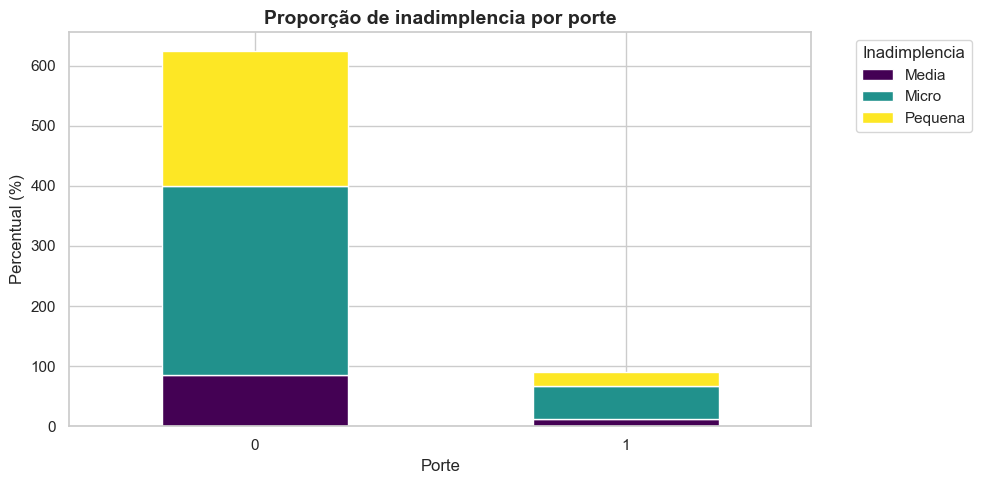

In [108]:
comparativo_colunas(df, 'inadimplencia', 'porte')